In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

import experiment_utils
from main import *
import plotstyle
plotstyle.set_plot_style()

In [3]:
import train_dt
argd = train_dt.Args()

argd.n_iters = 20000
argd.log_every = 10000

argd.opt.weight_decay = 1e-5

argd.model.layers = 8
argd.model.n_embd = 64
argd.model.n_head = 8
argd.model.block = "conv"

    # nt: int = 1 # number of patches in time dimension
    # nh: int = 16 # number of patches in height dimension
    # nw: int = 16 # number of patches in width dimension
    # pt: int = 1 # patch size in time dimension
    # ph: int = 1 # patch size in height dimension
    # pw: int = 1 # patch size in width dimension

grid_size = 64
argd.data.grid_size = grid_size


args_all = []
seeds_all = range(3)
dts_all = [1, 2, 4, 8, 16, 32, 64, 128]
gol_params_all = [ 6152, 7291, 7787]
# gol_params_all = [ 6152, 242251, 7291, 7787, 55871, 15923]
# gol_params_all = [2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
# gol_params_all = [6152, 242251, 7291, 7787, 55871, 15923, 2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
for seed in seeds_all:
    for gol_params in gol_params_all:
        for dt in dts_all:
            for block in ["attn"]:#, "attn"]:
                for ps in [1, 2, 4, 8, 16]:
                    args = copy.deepcopy(argd)
                    args.data.gol_params = gol_params
                    args.seed = seed
                    args.data.dt = dt

                    args.model.block = block
                    args.model.nt, args.model.nh, args.model.nw = 1, grid_size//ps, grid_size//ps
                    args.model.pt, args.model.ph, args.model.pw = 1, ps, ps
                    # if block == "attn":
                    #     args.model.nt, args.model.nh, args.model.nw = 1, 32, 32
                    #     args.model.pt, args.model.ph, args.model.pw = 1, 2, 2
                    # elif block == "conv":
                    #     args.model.nt, args.model.nh, args.model.nw = 1, 32, 32
                    #     args.model.pt, args.model.ph, args.model.pw = 1, 2, 2

                    # args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/run_4/seed={seed}_gol={gol_params}_dt={dt}_block={block}_ps={ps}"
                    args_all.append(args)
                    # print(args)
experiment_utils.create_commands(args_all, prefix="python train_dt.py", out_file="science_scripts/train_dt.sh");

In [4]:
import train_dt
import models.model_dt
args = args_all[1]

args = train_dt.Args(model=train_dt.DTNetworkConfig(layers=8, n_embd=64, n_head=8, block="conv", nt=1, nh=16, nw=16, pt=1, ph=4, pw=4))

main = train_dt.Main(args)
main.init()

# batch = main.generate_batch(rng)
# loss, metrics = main.loss_fn(main.train_state.params, batch)

Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=DTNetworkConfig(layers=8, n_embd=64, n_head=8, block='conv', nt=1, nh=16, nw=16, pt=1, ph=4, pw=4), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[1]))


Could not load symbol cuFuncGetName. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


Number of parameters: 564,304


In [5]:
rng = jax.random.PRNGKey(0)
for i in range(1):
    rng, _rng = split(rng)
    main.train_state, metrics = main.do_iter_train(main.train_state, _rng)
    # main.do_iter
    # main.step()
    # print(main.loss_history[-1])
    # params = jnp.concatenate([f.flatten() for f in jax.tree.leaves(main.train_state.params)])
    # print(params.mean().item())
    # print(metrics['loss'].mean().item())
    # grads = jnp.concatenate([f.flatten() for f in jax.tree.leaves(metrics['grads'])])
    # print(grads.mean().item())
    # print()

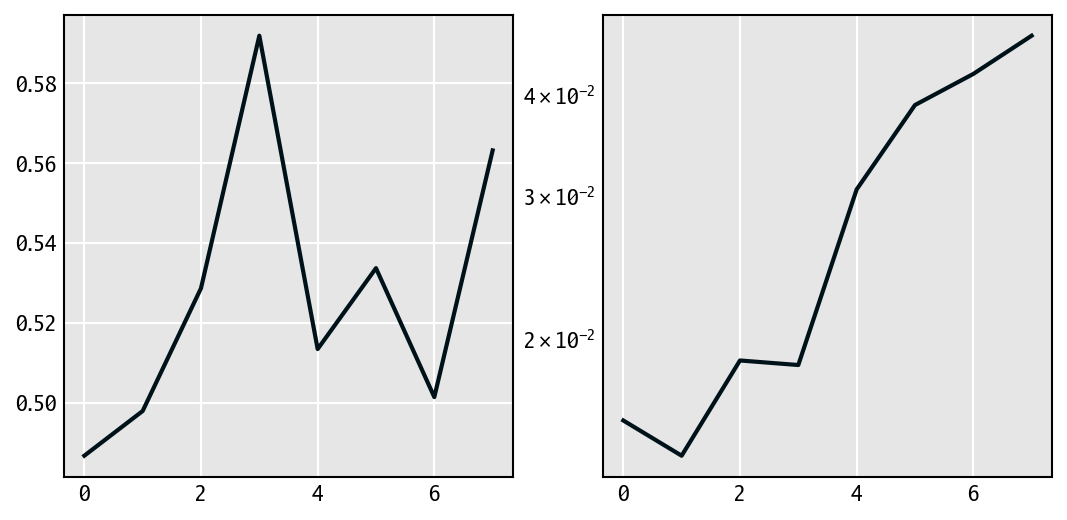

In [6]:
def flatten(a):
    return jnp.concatenate([f.flatten() for f in jax.tree.leaves(a)])
def flatten_abs_mean(a):
    return jnp.abs(flatten(a)).mean()

plt.subplot(121)
plt.plot(jnp.abs(metrics['features']).mean(axis=(0, -1, -2)))

grads = metrics['grads']
grads = [flatten_abs_mean(v).item() for k, v in list(grads['params'].items())[:-2]]
plt.subplot(122)
plt.plot(grads)
plt.yscale('log')

In [8]:
class Block(nn.Module):
    """A block of a CNN."""
    channels: int
    kernel_size: int = 3
    stride: int = 1
    padding: int = 1

    @nn.compact
    def __call__(self, x):
        identity = x
        x = nn.LayerNorm()(x)
        # x = nn.Conv(self.channels, self.kernel_size, self.stride, self.padding)(x)
        x = jnp.pad(x, pad_width=[(1, 1), (1, 1), (0, 0)], mode='wrap')
        x = nn.Conv(self.channels, (3, 3), (1, 1), padding='VALID')(x)
        x = nn.gelu(x)

        x = nn.LayerNorm()(x)
        # x = nn.Conv(self.channels, self.kernel_size, self.stride, self.padding)(x)
        x = jnp.pad(x, pad_width=[(1, 1), (1, 1), (0, 0)], mode='wrap')
        x = nn.Conv(self.channels, (3, 3), (1, 1), padding='VALID')(x)
        x = nn.gelu(x)

        x = identity + x
        return x
class ConvNet(nn.Module):
    layers: int
    channels: int
    out_channels: int = 1

    @nn.compact
    def __call__(self, x, return_features: bool = False):
        """
        x: (H, W)
        dt_id: int describing the which dt to use, 0 is the first dt, 1 is the second dt, etc.
        """
        features = []
        # x = jax.nn.one_hot(x, num_classes=2) # (H, W, 2)
        x = x[..., None].astype(float)
        x = nn.Conv(self.channels, 1, 1, 0)(x) # (H, W, D)
        for _ in range(self.layers):
            x = Block(self.channels)(x)
            features.append(x)
        x = nn.Conv(self.out_channels, 1, 1, 0, kernel_init=nn.initializers.normal(0.01))(x)
        x = x[..., 0]
        return (x, features) if return_features else x


In [9]:
from models.transformer import GPTConfig, MLP

class ConvBlock(nn.Module):
    n_embd: int
    kernel_size: int = 3

    def setup(self):
        # self.cfg = GPTConfig(n_embd=self.n_embd, n_head=0, dropout=0.)
        # self.ln_1 = nn.LayerNorm(epsilon=1e-5)
        # self.conv = nn.Conv(self.n_embd, (3, 3), (1, 1), padding='VALID')
        # self.ln_2 = nn.LayerNorm(epsilon=1e-5)
        # self.mlp = MLP(self.cfg)

        self.block = Block(channels=self.n_embd)

    def __call__(self, x):
        """
        x.shape: (T, D)
        """
        x = rearrange(x, "(N M) D -> N M D", N=int(np.sqrt(len(x))))

        # a = self.ln_1(x)
        # a = jnp.pad(a, pad_width=[(1, 1), (1, 1), (0, 0)], mode='wrap')
        # x = x + self.conv(a)
        # x = x + self.mlp(self.ln_2(x), train=True)

        # identity = x
        # x = self.ln_1(x)
        # x = jnp.pad(x, pad_width=[(1, 1), (1, 1), (0, 0)], mode='wrap')
        # x = self.conv(x)
        # x = nn.gelu(x)
        # x = x + identity

        x = self.block(x)

        x = rearrange(x, "N M D -> (N M) D")
        return x

@dataclass
class DTNetworkConfig:
    layers: int = 16
    n_embd: int = 64
    n_head: int = 0 # only used for transformer block
    block: str = "conv"

    nt: int = 1 # number of patches in time dimension
    nh: int = 64 # number of patches in height dimension
    nw: int = 64 # number of patches in width dimension
    pt: int = 1 # patch size in time dimension
    ph: int = 1 # patch size in height dimension
    pw: int = 1 # patch size in width dimension

class DTNetwork(nn.Module):
    cfg: DTNetworkConfig

    def setup(self):
        cfg = self.cfg
        self.Block = [ConvBlock(n_embd=self.cfg.n_embd) for _ in range(self.cfg.layers)]
        self.patch_embed = nn.Dense(cfg.n_embd)
        self.head = nn.Dense(cfg.pt*cfg.ph*cfg.pw)

    def __call__(self, x, return_features: bool = False):
        """
        x: (H, W)
        """
        cfg = self.cfg
        x_in = x
        x = x.astype(float)
        # convert to flattened patches
        x = rearrange(x, "H W -> 1 H W")
        x = rearrange(x, "(nt pt) (nh ph) (nw pw) -> (nt nh nw) (pt ph pw)",
                      nt=cfg.nt, nh=cfg.nh, nw=cfg.nw, pt=cfg.pt, ph=cfg.ph, pw=cfg.pw)
        # embed patches
        x = self.patch_embed(x)
        # add positional embeddings
        # forward encoder
        features = []
        for block in self.Block:
            x = block(x)
            features.append(x)
        features = jnp.stack(features)
        # project to patches
        x = self.head(x)
        # unflatten patches
        x = rearrange(x, "(nt nh nw) (pt ph pw) -> (nt pt) (nh ph) (nw pw)",
                      nt=cfg.nt, nh=cfg.nh, nw=cfg.nw, pt=cfg.pt, ph=cfg.ph, pw=cfg.pw)
        logits = rearrange(x, "1 H W -> H W")
        # probs = jax.nn.sigmoid(logits)
        # loss_ce = optax.losses.sigmoid_binary_cross_entropy(logits, y)
        # loss = loss_ce.mean()
        # metrics = dict(x=x_in, y=y, features=features, logits=logits, probs=probs, loss_ce=loss_ce, loss=loss)
        # return loss, metrics
        return logits


In [10]:
from models.transformer import GPTConfig, MLP

@dataclass
class DTNetworkConfig:
    layers: int = 16
    n_embd: int = 64
    n_head: int = 0 # only used for transformer block
    block: str = "conv"

    nt: int = 1 # number of patches in time dimension
    nh: int = 64 # number of patches in height dimension
    nw: int = 64 # number of patches in width dimension
    pt: int = 1 # patch size in time dimension
    ph: int = 1 # patch size in height dimension
    pw: int = 1 # patch size in width dimension

class DTNetwork(nn.Module):
    cfg: DTNetworkConfig

    def setup(self):
        cfg = self.cfg
        self.Block = [Block(channels=self.cfg.n_embd) for _ in range(self.cfg.layers)]
        self.patch_embed = nn.Dense(cfg.n_embd)
        self.head = nn.Dense(cfg.pt*cfg.ph*cfg.pw)

    def __call__(self, x, return_features: bool = False):
        """
        x: (H, W)
        """
        cfg = self.cfg
        # x = x.astype(float)
        x = jax.nn.one_hot(x, num_classes=2) # (H, W, 2)
        # convert to flattened patches
        # x = rearrange(x, "H W -> 1 H W")
        x = rearrange(x, "H W D -> 1 H W D")
        # x = rearrange(x, "(nt pt) (nh ph) (nw pw) -> (nt nh nw) (pt ph pw)",
                    #   nt=cfg.nt, nh=cfg.nh, nw=cfg.nw, pt=cfg.pt, ph=cfg.ph, pw=cfg.pw)
        x = rearrange(x, "(nt pt) (nh ph) (nw pw) D -> (nt nh nw) (pt ph pw D)",
                      nt=cfg.nt, nh=cfg.nh, nw=cfg.nw, pt=cfg.pt, ph=cfg.ph, pw=cfg.pw)
        # embed patches
        x = self.patch_embed(x)
        # forward encoder
        x = rearrange(x, "(N M) D -> N M D", N=int(np.sqrt(len(x))))
        features = []
        for block in self.Block:
            x = block(x)
            features.append(x)
        features = jnp.stack(features)
        x = rearrange(x, "N M D -> (N M) D")
        # project to patches
        x = self.head(x)
        # unflatten patches
        x = rearrange(x, "(nt nh nw) (pt ph pw) -> (nt pt) (nh ph) (nw pw)",
                      nt=cfg.nt, nh=cfg.nh, nw=cfg.nw, pt=cfg.pt, ph=cfg.ph, pw=cfg.pw)
        logits = rearrange(x, "1 H W -> H W")
        return logits


dict_keys(['Conv_0', 'Block_0', 'Block_1', 'Block_2', 'Block_3', 'Block_4', 'Block_5', 'Block_6', 'Block_7', 'Block_8', 'Block_9', 'Block_10', 'Block_11', 'Block_12', 'Block_13', 'Block_14', 'Block_15', 'Conv_1'])
1185985
{'bias': (64,), 'kernel': (1, 1, 64)}
{'bias': (1,), 'kernel': (1, 64, 1)}
0.8626162
dict_keys(['patch_embed', 'Block_0', 'Block_1', 'Block_2', 'Block_3', 'Block_4', 'Block_5', 'Block_6', 'Block_7', 'Block_8', 'Block_9', 'Block_10', 'Block_11', 'Block_12', 'Block_13', 'Block_14', 'Block_15', 'head'])
1186049
{'bias': (64,), 'kernel': (2, 64)}
{'bias': (1,), 'kernel': (64, 1)}
1.8214831


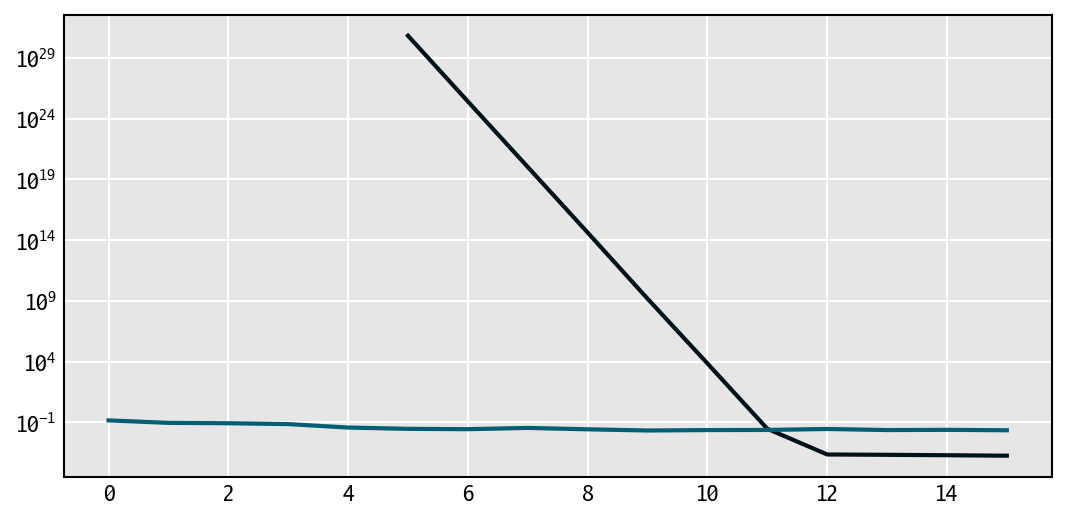

In [152]:
net1 = ConvNet(layers=16, channels=64)
net2 = DTNetwork(DTNetworkConfig(layers=16, n_embd=64))

for net in [net1, net2]:
    rng = jax.random.PRNGKey(0)
    batch = main.generate_batch(rng)
    params = net.init(rng, batch['x0'][0])
    print(params['params'].keys())
    print(sum(x.size for x in jax.tree.leaves(params)))

    for p in params['params']:
        if "Block" not in p:
            print(jax.tree.map(lambda x: x.shape, params['params'][p]))

    def loss_fn(params, x, y):
        logits = jax.vmap(net.apply, in_axes=(None, 0))(params, x)
        loss_ce = optax.sigmoid_binary_cross_entropy(logits, y)
        loss = loss_ce.mean()
        return loss
    def get_grads(params, x, y):
        loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
        return loss, grads

    loss, grads = get_grads(params, batch['x0'], batch['x1'])
    print(loss)
    grads = [flatten_abs_mean(grads['params'][f'Block_{i}']).item() for i in range(16)]
    plt.plot(grads)
    plt.yscale('log')

In [ ]:
1.0085552
0.8626162

(16, 64, 64, 64)
0.8626162
(16, 64, 64, 64)
1.0085552


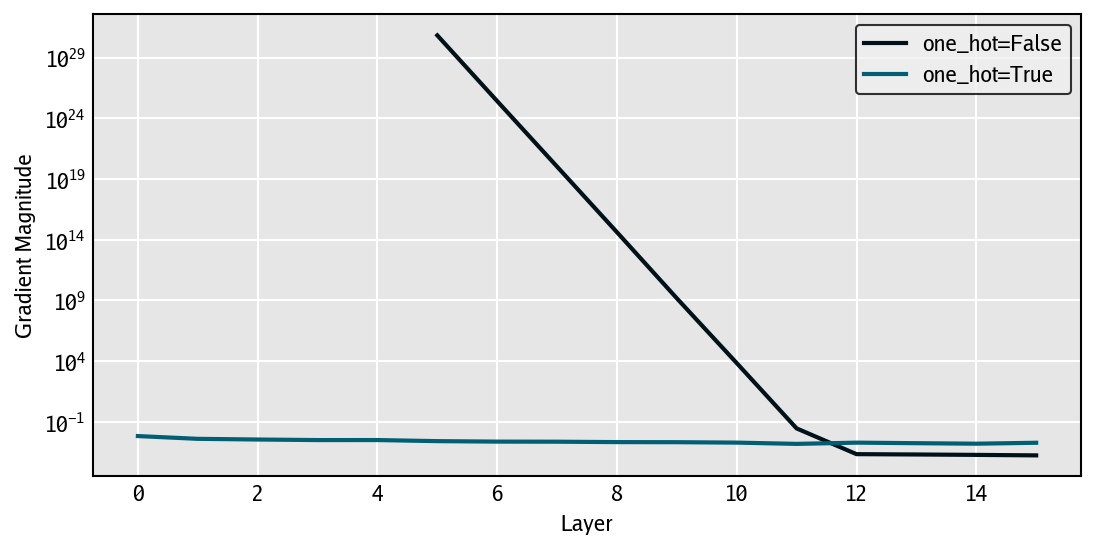

In [13]:
class ConvNet(nn.Module):
    layers: int
    channels: int
    out_channels: int = 1
    use_one_hot: bool = False

    @nn.compact
    def __call__(self, x, return_features: bool = False):
        """
        x: (H, W)
        dt_id: int describing the which dt to use, 0 is the first dt, 1 is the second dt, etc.
        """
        features = []
        if self.use_one_hot:
            x = jax.nn.one_hot(x, num_classes=2) # (H, W, 2)
        else:
            x = x[..., None].astype(float)
        x = nn.Conv(self.channels, 1, 1, 0)(x) # (H, W, D)
        # x = nn.Conv(self.channels, 1, 1, 0, bias_init=nn.initializers.normal(0.01))(x) # (H, W, D)
        for _ in range(self.layers):
            features.append(x)
            x = Block(self.channels)(x)
        x = nn.Conv(self.out_channels, 1, 1, 0, kernel_init=nn.initializers.normal(0.01))(x)
        x = x[..., 0]
        return (x, jnp.stack(features)) if return_features else x


net1 = ConvNet(layers=16, channels=64, use_one_hot=False)
net2 = ConvNet(layers=16, channels=64, use_one_hot=True)

f = []

for net in [net1, net2]:
    rng = jax.random.PRNGKey(0)
    batch = main.generate_batch(rng)
    params = net.init(rng, batch['x0'][0])
    # print(params['params'].keys())
    # print(sum(x.size for x in jax.tree.leaves(params)))

    # for p in params['params']:
        # if "Block" not in p:
            # print(jax.tree.map(lambda x: x.shape, params['params'][p]))

    def loss_fn(params, x, y):
        logits = jax.vmap(net.apply, in_axes=(None, 0))(params, x)
        loss_ce = optax.sigmoid_binary_cross_entropy(logits, y)
        loss = loss_ce.mean()
        return loss
    def get_grads(params, x, y):
        loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
        return loss, grads
    
    _, features = net.apply(params, batch['x0'][0], return_features=True)
    f.append(features)
    print(jax.tree.map(lambda x: x.shape, features))

    loss, grads = get_grads(params, batch['x0'], batch['x1'])
    print(loss)
    grads = [flatten_abs_mean(grads['params'][f'Block_{i}']).item() for i in range(16)]
    plt.plot(grads, label=f"one_hot={net.use_one_hot}")
    plt.yscale('log')

plt.ylabel("Gradient Magnitude")
plt.xlabel("Layer")
plt.legend()


(16, 64, 64, 64)


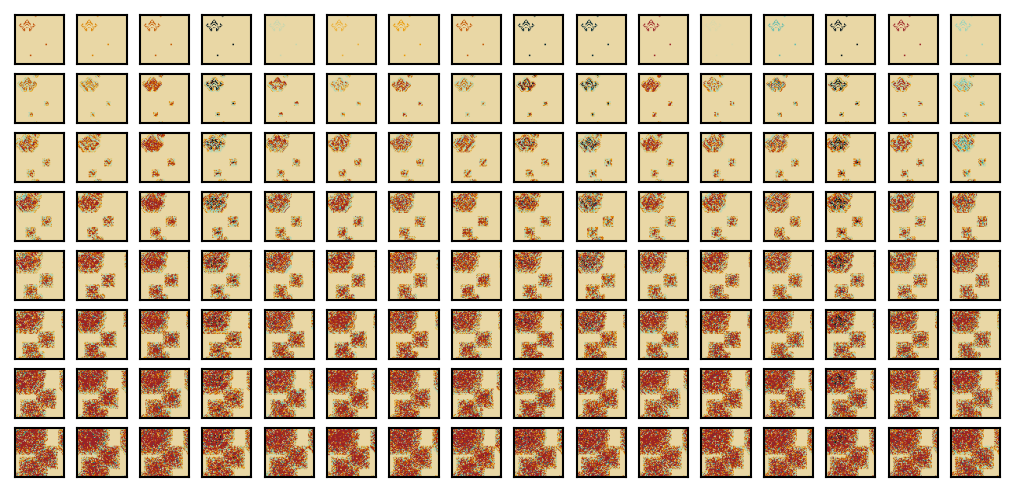

(16, 64, 64, 64)


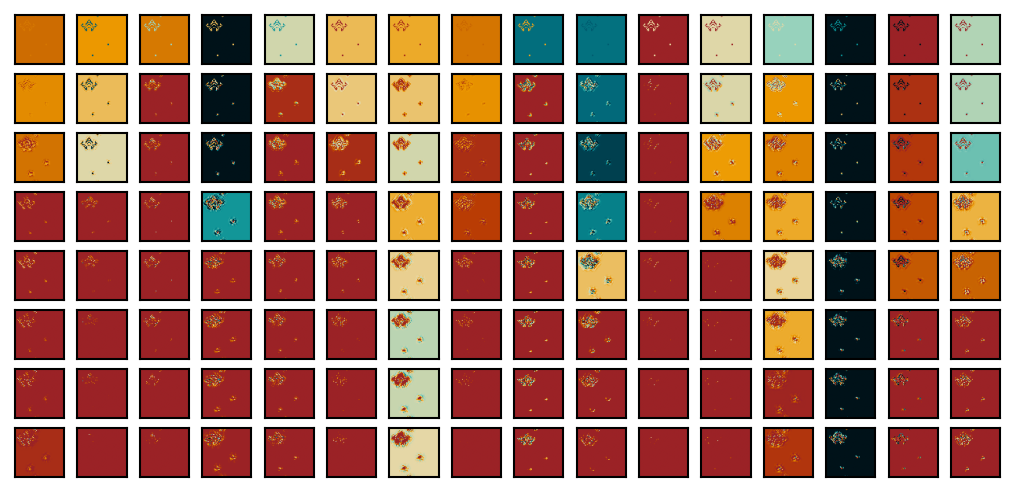

In [14]:
for features in f:
    print(features.shape)
    # plt.figure(figsize=(16, 8))
    iplt = 0
    for i in range(8):
        for j in range(0, 64, 4):
            iplt += 1
            plt.subplot(8, 16, iplt)
            plt.imshow(features[i, :, :, j], vmin=-1, vmax=1.); plt.xticks([]); plt.yticks([])
    plt.show()

In [15]:
print(f[0][0, 6, 14, :])
print(f[0][0, 7, 15, :])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 0.6723196  -0.28954548  0.4659113  -1.2064617   0.36801636  0.83032304
 -0.26398987 -0.4805655   0.58036333 -0.54102707  0.0738063   1.0612576
 -1.5339106   0.27038947 -0.796437    0.4657949  -0.10363274  0.02635108
 -0.07966035  0.3946948   0.17155737 -2.0798414   0.954605    0.22136211
  0.2639323   0.51774305 -0.9847821   1.9534613   0.60652083 -1.0193688
  0.66270953 -1.563264   -0.9579888   1.7003789   1.9872718  -1.6905267
 -0.93365616  1.5702735  -1.4858063  -0.29529747  1.5412302   1.2057418
  0.67615247  0.18817383 -0.03926422 -0.45167074 -2.2373059   1.062477
 -0.33687317 -0.32806557 -0.4287848   0.66147125 -1.8525406   1.9656285
  0.42625996 -0.43894336  1.4327532  -1.6668501  -1.5781153  -1.2899892
 -0.2304964  -0.79836863  0.51426697 -0.07047678]


In [12]:
jax.tree.map(lambda x: x.max().item(), metrics['grads'])

{'params': {'blocks_0': {'Conv_0': {'bias': 3.0271704307376718e+35,
    'kernel': 0.0007951800362206995},
   'Conv_1': {'bias': 4.695417592069124e+32, 'kernel': 0.0006021832232363522},
   'LayerNorm_0': {'bias': 2.3678837741067543e+35,
    'scale': 0.0002202182513428852},
   'LayerNorm_1': {'bias': 6.2841140146605746e+32,
    'scale': 0.00021907262271270156}},
  'blocks_1': {'Conv_0': {'bias': 1.1704605201175858e+30,
    'kernel': 0.0004942307714372873},
   'Conv_1': {'bias': 2.4992811753808107e+27, 'kernel': 0.0005005897837691009},
   'LayerNorm_0': {'bias': 9.70331917624031e+29,
    'scale': 0.00011549901682883501},
   'LayerNorm_1': {'bias': 2.3552106284256132e+27,
    'scale': 0.00015839061234146357}},
  'blocks_2': {'Conv_0': {'bias': 4.585439760375013e+24,
    'kernel': 0.0003564921207726002},
   'Conv_1': {'bias': 8.673559083546504e+21, 'kernel': 0.0002452641783747822},
   'LayerNorm_0': {'bias': 4.950644364321049e+24,
    'scale': 9.14947158889845e-05},
   'LayerNorm_1': {'bias

In [5]:
jax.tree.map(lambda x: x.shape, metrics)

{'features': [],
 'logits': (32, 64, 64),
 'loss': (32,),
 'loss_ce': (32, 64, 64),
 'probs': (32, 64, 64),
 'x': (32, 64, 64),
 'y': (32, 64, 64)}

In [6]:
metrics['loss']

Array([0.69434273, 0.6943357 , 0.69489604, 0.6950116 , 0.69483423,
       0.6948066 , 0.6949329 , 0.69472134, 0.69477457, 0.6948825 ,
       0.6947188 , 0.69490284, 0.6947933 , 0.6948396 , 0.69477546,
       0.69495505, 0.6949939 , 0.69471836, 0.69505   , 0.695143  ,
       0.6952158 , 0.69480234, 0.6948981 , 0.69463587, 0.6951151 ,
       0.69519734, 0.6950835 , 0.69478536, 0.6948266 , 0.6951711 ,
       0.69503784, 0.6950677 ], dtype=float32)

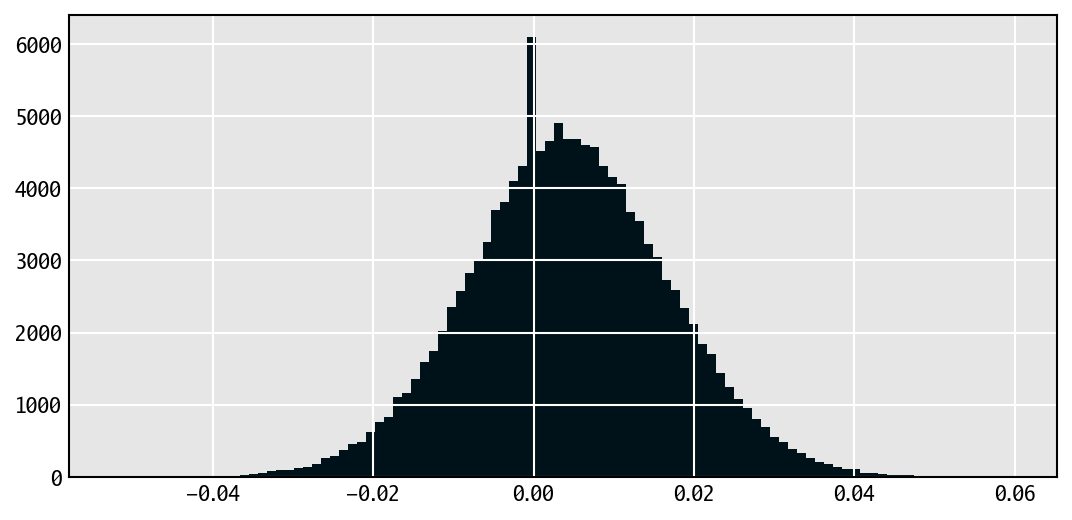

In [7]:
plt.hist(metrics['logits'].flatten(), bins=100);

In [ ]:
python main.py --seed=0    --n_iters=50000 --log_every=10000 --model.layers=8 --model.channels=64 --model.out_channels=2 --model.n_dts=1 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=1e-05 --opt.clip_grad_norm=1.0 --data.gol_params=6152   --data.grid_size=64 --data.t_start=32 --data.t_end=64 --data.dt=1  

In [ ]:
import train_dt
argd = train_dt.Args()

argd.n_iters = 50000
argd.log_every = 10000

argd.opt.weight_decay = 1e-5

argd.model.layers = 8
argd.model.n_embd = 64
argd.model.n_head = 8
argd.model.block = "conv"

    # nt: int = 1 # number of patches in time dimension
    # nh: int = 16 # number of patches in height dimension
    # nw: int = 16 # number of patches in width dimension
    # pt: int = 1 # patch size in time dimension
    # ph: int = 1 # patch size in height dimension
    # pw: int = 1 # patch size in width dimension

grid_size = 64
argd.data.grid_size = grid_size

ps = 2

args_all = []
seeds_all = range(3)
dts_all = [1, 2, 4, 8, 16, 32, 64, 128]
gol_params_all = [ 6152, 7291, 7787]
# gol_params_all = [ 6152, 242251, 7291, 7787, 55871, 15923]
# gol_params_all = [2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
# gol_params_all = [6152, 242251, 7291, 7787, 55871, 15923, 2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
for seed in seeds_all:
    for gol_params in gol_params_all:
        for dt in dts_all:
            for block in ["conv", "attn"]:
                args = copy.deepcopy(argd)
                args.data.gol_params = gol_params
                args.seed = seed
                args.data.dt = dt

                args.model.block = block
                args.model.nt, args.model.nh, args.model.nw = 1, grid_size//ps, grid_size//ps
                args.model.pt, args.model.ph, args.model.pw = 1, ps, ps
                # if block == "attn":
                #     args.model.nt, args.model.nh, args.model.nw = 1, 32, 32
                #     args.model.pt, args.model.ph, args.model.pw = 1, 2, 2
                # elif block == "conv":
                #     args.model.nt, args.model.nh, args.model.nw = 1, 32, 32
                #     args.model.pt, args.model.ph, args.model.pw = 1, 2, 2

                args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/run_3/seed={seed}_gol={gol_params}_dt={dt}_block={block}"
                args_all.append(args)
                # print(args)
# experiment_utils.create_commands(args_all, prefix="python train_dt.py", out_file="science_scripts/train_dt.sh");

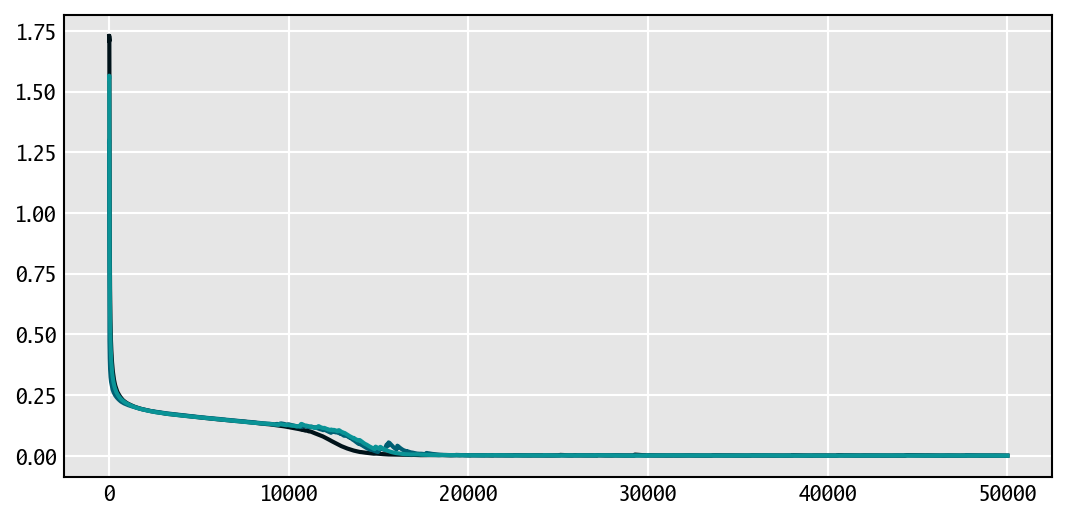

In [ ]:
for args in args_all:
    if args.model.block == "conv" and args.data.gol_params == 7291 and args.data.dt == 4:
        loss_history = util.load_pkl(args.save_dir, "loss_history")
        # plt.plot(loss_history, linewidth=1)
        plt.plot(pd.DataFrame(loss_history).ewm(span=1000).mean())
# plt.ylim(-.01, 1)
plt.show()

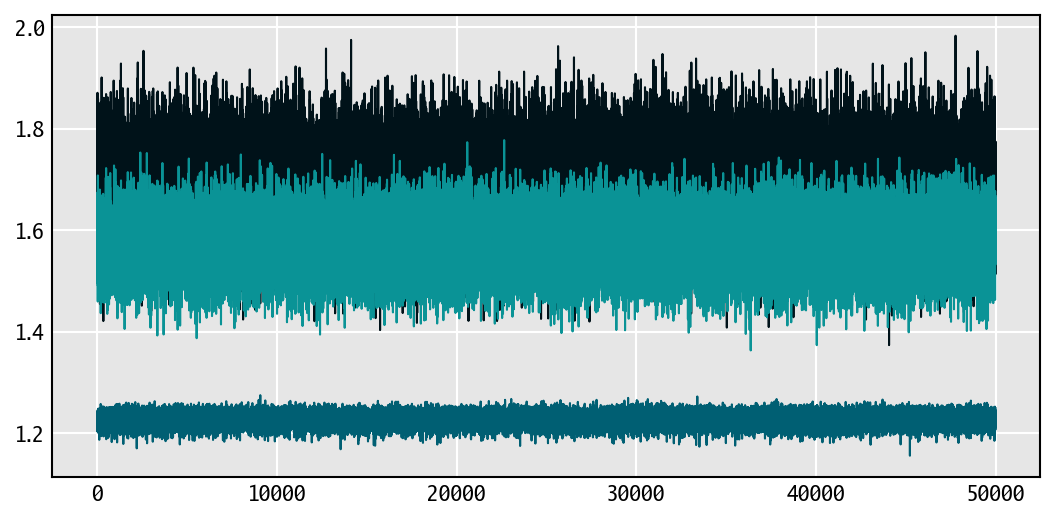

In [ ]:
for args in args_all:
    if args.model.block == "conv" and args.data.gol_params == 7787 and args.data.dt == 4:
        loss_history = util.load_pkl(args.save_dir, "loss_history")
        plt.plot(loss_history, linewidth=1)
        # plt.plot(pd.DataFrame(loss_history).ewm(span=1000).mean())
# plt.ylim(-.01, 1)
plt.show()

In [ ]:
args = args_all[4+16+16]
main = train_dt.Main(args)
main.init()

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_3/seed=0_gol=7787_dt=4_block=conv', n_iters=50000, log_every=10000, model=DTNetworkConfig(layers=8, n_embd=64, n_head=8, block='conv', nt=1, nh=32, nw=32, pt=1, ph=2, pw=2), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7787, grid_size=64, t_start=32, t_end=64, dt=[4]))
Number of parameters: 562,756


In [ ]:
rng = jax.random.PRNGKey(0)
params = util.load_pkl(args.save_dir, "params")
batch = main.generate_batch(rng)
loss, metrics = main.loss_fn(params, batch)

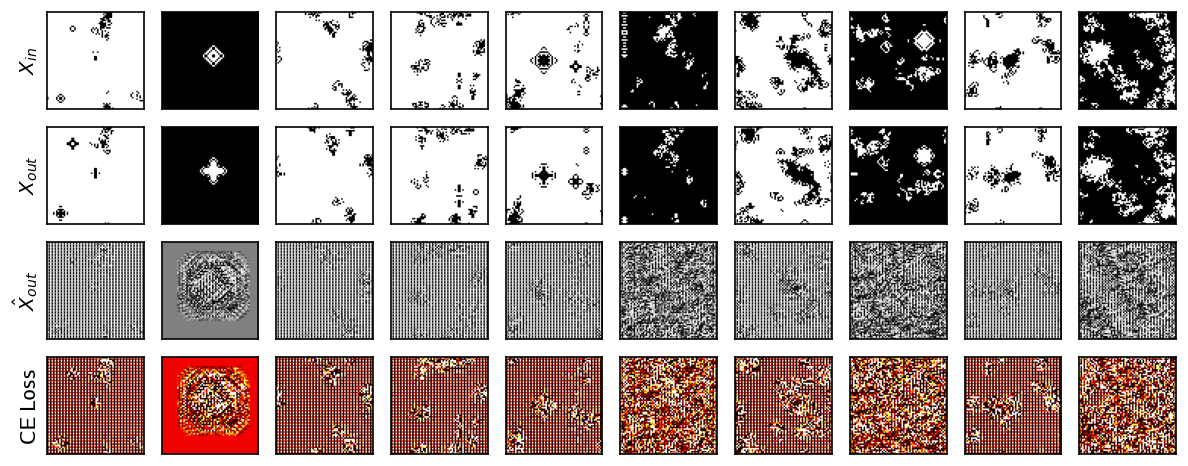

In [ ]:
def put_border(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
    ax.set_xticks([])
    ax.set_yticks([])
n_samples = 10
fig, axs = plt.subplots(4, n_samples, figsize=(n_samples, 4), dpi=120)
for i in range(n_samples):
    x, y = metrics['x'][i], metrics['y'][i]
    probs, loss_ce = metrics['probs'][i], metrics['loss_ce'][i]
    plt.sca(axs[0, i]); plt.imshow(x, cmap='gray'); put_border(plt.gca())
    if i==0: plt.ylabel("$X_{in}$", fontsize=12)
    plt.sca(axs[1, i]); plt.imshow(y, cmap='gray'); put_border(plt.gca())
    if i==0: plt.ylabel("$X_{out}$", fontsize=12)
    plt.sca(axs[2, i]); plt.imshow(probs, cmap='gray'); put_border(plt.gca())
    if i==0: plt.ylabel("$\hat{X}_{out}$", fontsize=12)
    plt.sca(axs[3, i]); plt.imshow(loss_ce, cmap='hot', vmin=0., vmax=2.); put_border(plt.gca())
    if i==0: plt.ylabel("CE Loss", fontsize=12)
plt.tight_layout()
# plt.suptitle(f"GoL World: {gol_params}, $\Delta t=${dt}", fontsize=12, y=1.01)
plt.show()

In [ ]:
df = []
for args in args_all:
    # args = util.load_pkl(args.load_dir, "args")
    final_loss = util.load_pkl(args.save_dir, "final_loss")
    # metrics = util.load_pkl(lp_args.save_dir, "metrics")
    dfi = dict(dt=args.data.dt, seed=args.seed, gol_params=args.data.gol_params, final_loss=final_loss, block=args.model.block)
    # dfi = {**dfi, **metrics}
    df.append(dfi)
df = pd.DataFrame(df)

In [ ]:
df

,dt,seed,gol_params,final_loss,block
0,1,0,6152,1.202369e-09,conv
1,1,0,6152,1.871120e-01,attn
2,2,0,6152,6.700075e-08,conv
3,2,0,6152,2.177564e-01,attn
4,4,0,6152,1.639919e-05,conv
...,...,...,...,...,...
139,32,2,7787,2.606670e-01,attn
140,64,2,7787,1.564860e+00,conv
141,64,2,7787,2.367969e-01,attn
142,128,2,7787,1.570151e+00,conv


In [ ]:
import train_dt

gol2randloss = {}

rng = jax.random.PRNGKey(0)
for gol_params in df.gol_params.unique():
    args = train_dt.Args(data=train_dt.DataArgs(gol_params=gol_params))
    main = train_dt.Main(args)
    x = jax.vmap(main.generate_batch)(split(rng, 10))['state']
    x = x[:, :, ::2, :, :] # skip every other frame to remove flashing
    print(x.shape)
    p = x.mean().item()
    h = -p*np.log(p) - (1-p)*np.log(1-p)
    gol2randloss[gol_params.item()] = dict(p=p, h=h.item())

Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=DTNetworkConfig(layers=8, n_embd=64, n_head=8, block='conv', nt=1, nh=16, nw=16, pt=1, ph=1, pw=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=np.int64(6152), grid_size=64, t_start=32, t_end=64, dt=[1]))
(10, 32, 33, 64, 64)
Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=DTNetworkConfig(layers=8, n_embd=64, n_head=8, block='conv', nt=1, nh=16, nw=16, pt=1, ph=1, pw=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=np.int64(7291), grid_size=64, t_start=32, t_end=64, dt=[1]))
(10, 32, 33, 64, 64)
Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=DTNetworkConfig(layers=8, n_embd=64, n_head=8, block='conv', nt=1, nh=16, nw=16, pt=1, ph=1, pw=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), dat

In [ ]:
gol2randloss

{6152: {'p': 0.12816347181797028, 'h': 0.3828805709336809},
 7291: {'p': 0.19461151957511902, 'h': 0.4928410466522111},
 7787: {'p': 0.16282008588314056, 'h': 0.44431677780233764}}

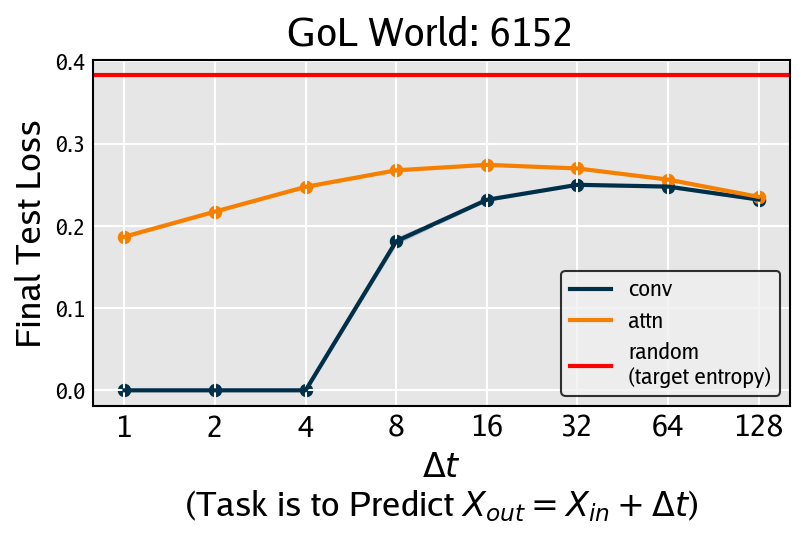

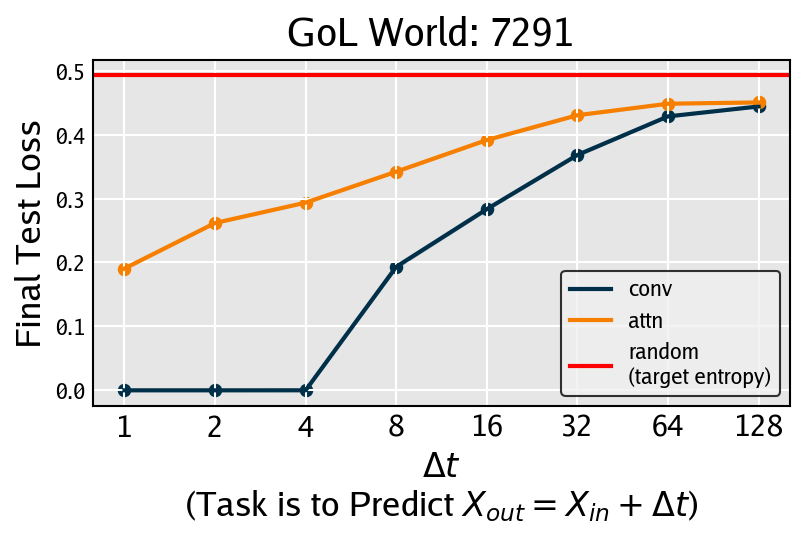

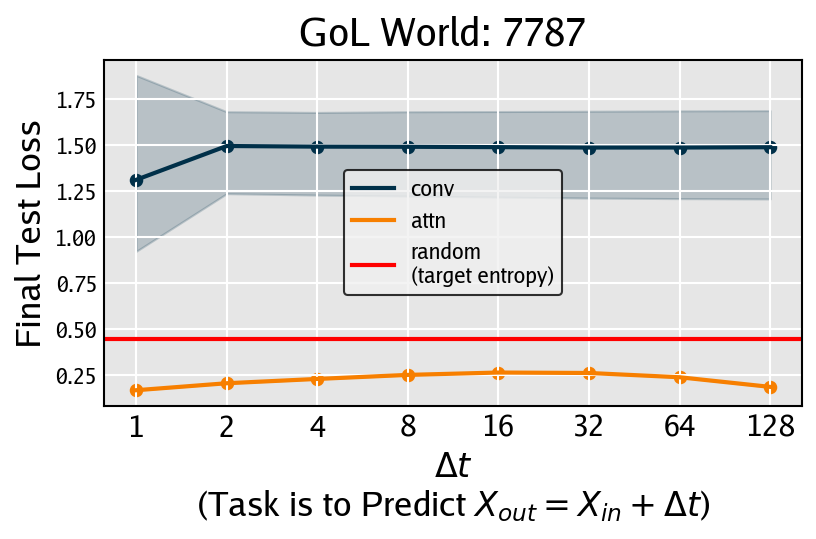

In [ ]:
for gol_params in df.gol_params.unique():
    a = df[(df.gol_params==gol_params) & (df.block=="conv")]
    b = df[(df.gol_params==gol_params) & (df.block=="attn")]

    plt.figure(figsize=(6, 3))
    # plt.figure(figsize=(10, 5), d)
    # plt.subplot(131)
    sns.lineplot(data=a, x="dt", y="final_loss", color='#003049', label="conv")
    sns.lineplot(data=b, x="dt", y="final_loss", color='#f77f00', label="attn")
    plt.scatter(a.dt.unique(), a.groupby("dt")['final_loss'].mean(), color='#003049', s=30, marker='o')
    plt.scatter(b.dt.unique(), b.groupby("dt")['final_loss'].mean(), color='#f77f00', s=30, marker='o')

    plt.axhline(y=gol2randloss[gol_params]['h'], color='red', label="random\n(target entropy)")
    plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    plt.ylabel("Final Test Loss", fontsize=16)
    plt.xlabel("$\Delta t$\n(Task is to Predict $X_{out}=X_{in}+\Delta t$)", fontsize=16)
    plt.legend(fontsize=10)
    # plt.yscale('log'); plt.ylim(1e-2, 1e0)

    # plt.subplot(132)
    # sns.lineplot(data=a, x="dt", y="score_test", color='black', label="trained representation")
    # plt.scatter(a.dt.unique(), a.groupby("dt")['score_test'].mean(), color='black', s=30, marker='o')
    # sns.lineplot(data=b, x="dt", y="score_test", color='red', label="random representation")
    # plt.scatter(b.dt.unique(), b.groupby("dt")['score_test'].mean(), color='red', s=30, marker='o')
    # plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    # plt.ylabel("$R^2$ to CLIP($X_{in}$)", fontsize=16)
    # plt.xlabel("$\Delta t$", fontsize=16)
    # plt.legend(fontsize=14)

    # a = df[(df.gol_params==gol_params) & (df.ablate_features=="none") & (df.target=="x1")]
    # b = df[(df.gol_params==gol_params) & (df.ablate_features=="random") & (df.target=="x1")]
    
    # plt.subplot(133)
    # sns.lineplot(data=a, x="dt", y="score_test", color='black', label="trained representation")
    # plt.scatter(a.dt.unique(), a.groupby("dt")['score_test'].mean(), color='black', s=30, marker='o')
    # sns.lineplot(data=b, x="dt", y="score_test", color='red', ax=plt.gca(), label="random representation")
    # plt.scatter(b.dt.unique(), b.groupby("dt")['score_test'].mean(), color='red', s=30, marker='o')
    # plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    # plt.ylabel("$R^2$ to CLIP($X_{out}$)", fontsize=16)
    # plt.xlabel("$\Delta t$", fontsize=16)
    # plt.legend(fontsize=14)

    plt.suptitle(f"GoL World: {gol_params}", fontsize=18)
    plt.show()
    # break

In [ ]:
main0 = train_dt.Main(args_all[0])
main0.init()
main1 = train_dt.Main(args_all[1])
main1.init()

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_3/seed=0_gol=6152_dt=1_block=conv', n_iters=50000, log_every=10000, model=DTNetworkConfig(layers=8, n_embd=64, n_head=8, block='conv', nt=1, nh=32, nw=32, pt=1, ph=2, pw=2), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[1]))
Number of parameters: 562,756
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_3/seed=0_gol=6152_dt=1_block=attn', n_iters=50000, log_every=10000, model=DTNetworkConfig(layers=8, n_embd=64, n_head=8, block='attn', nt=1, nh=32, nw=32, pt=1, ph=2, pw=2), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[1]))
Number of parameters: 400,452


In [ ]:
jax.tree.map(lambda x: (x.shape, x.size), main0.init_params['params']['blocks_0'])

{'conv': {'bias': ((64,), 64), 'kernel': ((3, 3, 64, 64), 36864)},
 'ln_1': {'bias': ((64,), 64), 'scale': ((64,), 64)},
 'ln_2': {'bias': ((64,), 64), 'scale': ((64,), 64)},
 'mlp': {'c_fc': {'bias': ((256,), 256), 'kernel': ((64, 256), 16384)},
  'c_proj': {'bias': ((64,), 64), 'kernel': ((256, 64), 16384)}}}

In [ ]:
jax.tree.map(lambda x: (x.shape, x.size), main1.init_params['params']['blocks_0'])

{'attn': {'c_attn': {'bias': ((192,), 192), 'kernel': ((64, 192), 12288)},
  'c_proj': {'bias': ((64,), 64), 'kernel': ((64, 64), 4096)}},
 'ln_1': {'bias': ((64,), 64), 'scale': ((64,), 64)},
 'ln_2': {'bias': ((64,), 64), 'scale': ((64,), 64)},
 'mlp': {'c_fc': {'bias': ((256,), 256), 'kernel': ((64, 256), 16384)},
  'c_proj': {'bias': ((64,), 64), 'kernel': ((256, 64), 16384)}}}

In [ ]:
import flax.linen as nn
net = nn.MultiHeadDotProductAttention(num_heads=8)
rng = jax.random.PRNGKey(0)
x = jnp.zeros((1024, 64))
params = net.init(rng, x)

In [ ]:
jax.tree.map(lambda x: (x.shape, x.size), params['params'])

{'key': {'bias': ((8, 8), 64), 'kernel': ((64, 8, 8), 4096)},
 'out': {'bias': ((64,), 64), 'kernel': ((8, 8, 64), 4096)},
 'query': {'bias': ((8, 8), 64), 'kernel': ((64, 8, 8), 4096)},
 'value': {'bias': ((8, 8), 64), 'kernel': ((64, 8, 8), 4096)}}

In [ ]:
net = nn.MultiHeadDotProductAttention(num_heads=8)
rng = jax.random.PRNGKey(0)
x = jnp.zeros((1024, 64))
params = net.init(rng, x)

def loss_fn(params, x):
    y = jax.vmap(net.apply, in_axes=(None, 0))(params, x)
    return (y-x).mean()

@jax.jit
def test_attn(rng):
    x = jax.random.normal(rng, (32, 1024, 64))
    grads = jax.grad(loss_fn)(params, x)
    return grads

a = []
for i in tqdm(range(400000)):
    rng = jax.random.PRNGKey(i)
    ai = test_attn(rng)
    ai = sum(x.mean().item() for x in jax.tree.leaves(ai))
    a.append(ai)

  1%|          | 3638/400000 [00:23<43:01, 153.53it/s] 


KeyboardInterrupt: 

In [ ]:
from models.transformer import CausalSelfAttention, GPTConfig
net = CausalSelfAttention(config=GPTConfig(n_embd=64, n_head=8, dropout=0.0))
rng = jax.random.PRNGKey(0)
x = jnp.zeros((1, 1024, 64))
params = net.init(rng, x, train=True)

def loss_fn(params, x):
    y = partial(net.apply, train=True)(params, x)
    return (y-x).mean()

@jax.jit
def test_attn(rng):
    x = jax.random.normal(rng, (32, 1024, 64))
    grads = jax.grad(loss_fn)(params, x)
    return grads

a = []
for i in tqdm(range(400000)):
    rng = jax.random.PRNGKey(i)
    ai = test_attn(rng)
    ai = sum(x.mean().item() for x in jax.tree.leaves(ai))
    a.append(ai)

  2%|▏         | 7672/400000 [00:42<36:15, 180.35it/s] 


KeyboardInterrupt: 

In [ ]:
python train_dt.py --seed=0  --n_iters=50000 --log_every=10000 --model.layers=8 --model.n_embd=64 --model.n_head=8 --model.block="attn" --model.nt=1 --model.nh=32 --model.nw=32 --model.pt=1 --model.ph=2 --model.pw=2 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=1e-05 --opt.clip_grad_norm=1.0 --data.gol_params=6152 --data.grid_size=64 --data.t_start=32 --data.t_end=64 --data.dt=1  

In [ ]:
import main
argd = main.Args()


argd.n_iters = 50000
argd.log_every = 10000

args_all = []
seeds_all = range(5)
dts_all = [1, 2, 4, 8, 16, 32, 64, 128]
gol_params_all = [ 6152, 242251, 7291, 7787, 55871, 15923]
# gol_params_all = [2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
# gol_params_all = [6152, 242251, 7291, 7787, 55871, 15923, 2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
for seed in seeds_all:
    for gol_params in gol_params_all:
        for dt in dts_all:
            args = copy.deepcopy(argd)
            args.data.gol_params = gol_params
            args.seed = seed
            args.data.dt = dt
            args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params={gol_params}_dt={dt}_seed={seed}"
            args_all.append(args)
            print(args)
experiment_utils.create_commands(args_all, prefix="python main.py", out_file="science_scripts/main.sh");

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=1))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=2_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=2))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=4_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, 

In [ ]:
import linear_probe
argd = linear_probe.LinearProbeArgs()

argd.n_iters = 1000

lp_args_all = []
for args in args_all:
    for ablate_features in ["none", "random"]:
        for target in ["x0", "x1"]:
            lp_args = copy.deepcopy(argd)
            lp_args.seed = args.seed
            lp_args.load_dir = args.save_dir
            lp_args.save_dir = f"{args.save_dir}_lp_{ablate_features}_{target}"
            lp_args.ablate_features = ablate_features
            lp_args.target = target
            lp_args_all.append(lp_args)
            print(lp_args)
experiment_utils.create_commands(lp_args_all, prefix="python linear_probe.py", out_file="science_scripts/linear_probe.sh");

LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0_lp_none_x0', n_iters=1000, ablate_features='none', target='x0')
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0_lp_none_x1', n_iters=1000, ablate_features='none', target='x1')
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0_lp_random_x0', n_iters=1000, ablate_features='random', target='x0')
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_2/gol_params=6152_dt=1_seed=0_lp_random_x1', n_iters=1000, ablate_

In [ ]:
pd.DataFrame([experiment_utils.dataclass_to_flat_dict(args) for args in args_all])

,seed,save_dir,n_iters,log_every,model.layers,model.channels,model.out_channels,model.n_dts,opt.batch_size,opt.learning_rate,opt.weight_decay,opt.clip_grad_norm,data.gol_params,data.grid_size,data.t_start,data.t_end,data.dt
0,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,1
1,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,2
2,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,4
3,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,8
4,0,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,6152,64,32,64,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,4,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,15923,64,32,64,8
236,4,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,15923,64,32,64,16
237,4,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,15923,64,32,64,32
238,4,/home/akarsh_sakana_ai/alife-repr-data/run_2/g...,50000,10000,8,64,2,1,32,0.0003,0.00001,1.0,15923,64,32,64,64


In [ ]:
df = []
for lp_args in lp_args_all:
    try:
        args = util.load_pkl(lp_args.load_dir, "args")
        final_loss = util.load_pkl(args.save_dir, "final_loss")
        metrics = util.load_pkl(lp_args.save_dir, "metrics")
        dfi = dict(dt=args.data.dt[0], seed=args.seed, gol_params=args.data.gol_params,
                   ablate_features=lp_args.ablate_features, target=lp_args.target, final_loss=final_loss)
        dfi = {**dfi, **metrics}
        df.append(dfi)
    except:
        pass
df = pd.DataFrame(df)

In [ ]:
df

,dt,seed,gol_params,ablate_features,target,final_loss,score_train,score_test,mse_train,mse_test,cossim_train,cossim_test
0,1,0,6152,none,x0,4.547473e-14,0.283923,0.281220,0.000040,0.000040,0.98979396,0.9897014
1,1,0,6152,none,x1,4.547473e-14,0.281037,0.278497,0.000040,0.000040,0.98972845,0.98965317
2,1,0,6152,random,x0,4.547473e-14,0.321404,0.317939,0.000037,0.000038,0.99038595,0.9902851
3,1,0,6152,random,x1,4.547473e-14,0.309902,0.304639,0.000038,0.000039,0.99021477,0.9900964
4,2,0,6152,none,x0,7.241780e-11,0.271664,0.268111,0.000040,0.000041,0.989606,0.9894966
...,...,...,...,...,...,...,...,...,...,...,...,...
955,64,4,15923,random,x1,5.186090e-01,0.292970,0.291579,0.000077,0.000078,0.9801051,0.9799021
956,128,4,15923,none,x0,5.351270e-01,0.455008,0.452689,0.000052,0.000053,0.98648316,0.98640704
957,128,4,15923,none,x1,5.351270e-01,0.284834,0.281399,0.000084,0.000084,0.9782467,0.97811687
958,128,4,15923,random,x0,5.351270e-01,0.394643,0.394358,0.000059,0.000059,0.9848761,0.9848457


In [ ]:
for gol_params in df.gol_params.unique():
    a = df[(df.gol_params==gol_params) & (df.ablate_features=="none") & (df.target=="x0")]
    b = df[(df.gol_params==gol_params) & (df.ablate_features=="random") & (df.target=="x0")]

    plt.figure(figsize=(20, 5))

    plt.subplot(131)
    sns.lineplot(data=a, x="dt", y="final_loss", color='black', label="trained weights")
    plt.scatter(a.dt.unique(), a.groupby("dt")['final_loss'].mean(), color='black', s=30, marker='o')

    plt.axhline(y=np.log(2), color='red', label="random weights")
    plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    plt.ylabel("Final Test Loss", fontsize=16)
    plt.xlabel("$\Delta t$\n(Task is to Predict $X_{out}=X_{in}+\Delta t$)", fontsize=16)
    plt.legend(fontsize=14)
    plt.yscale('log'); plt.ylim(1e-2, 1e0)

    plt.subplot(132)
    sns.lineplot(data=a, x="dt", y="score_test", color='black', label="trained representation")
    plt.scatter(a.dt.unique(), a.groupby("dt")['score_test'].mean(), color='black', s=30, marker='o')
    sns.lineplot(data=b, x="dt", y="score_test", color='red', label="random representation")
    plt.scatter(b.dt.unique(), b.groupby("dt")['score_test'].mean(), color='red', s=30, marker='o')
    plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    plt.ylabel("$R^2$ to CLIP($X_{in}$)", fontsize=16)
    plt.xlabel("$\Delta t$", fontsize=16)
    plt.legend(fontsize=14)

    a = df[(df.gol_params==gol_params) & (df.ablate_features=="none") & (df.target=="x1")]
    b = df[(df.gol_params==gol_params) & (df.ablate_features=="random") & (df.target=="x1")]
    
    plt.subplot(133)
    sns.lineplot(data=a, x="dt", y="score_test", color='black', label="trained representation")
    plt.scatter(a.dt.unique(), a.groupby("dt")['score_test'].mean(), color='black', s=30, marker='o')
    sns.lineplot(data=b, x="dt", y="score_test", color='red', ax=plt.gca(), label="random representation")
    plt.scatter(b.dt.unique(), b.groupby("dt")['score_test'].mean(), color='red', s=30, marker='o')
    plt.xscale('log'); plt.xticks(a.dt.unique(), a.dt.unique(), fontsize=14)
    plt.ylabel("$R^2$ to CLIP($X_{out}$)", fontsize=16)
    plt.xlabel("$\Delta t$", fontsize=16)
    plt.legend(fontsize=14)

    plt.suptitle(f"GoL World: {gol_params}", fontsize=18)
    plt.show()
    # break

In [ ]:
dt = 16
for gol_params in df.gol_params.unique():
    a = df[(df.gol_params==gol_params) & (df.ablate_features=="none") & (df.target=="x0") & (df.dt==dt)]
    idx = a.index[a.final_loss.argmin()]
    lp_args = lp_args_all[idx]
    args = util.load_pkl(lp_args.load_dir, "args")

    from main import Main
    main = Main(args)

    params = util.load_pkl(args.save_dir, "params")
    rng = jax.random.PRNGKey(0)
    batch = main.generate_batch(rng)

    def put_border(ax):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color('black')
        ax.set_xticks([])
        ax.set_yticks([])

    n_samples = 10
    # plt.figure(figsize=(10, 2.5*n_samples))

    fig, axs = plt.subplots(4, n_samples, figsize=(n_samples, 4), dpi=100)
    for i in range(n_samples):
        x0, x1 = batch['x0'], batch['x1']
        loss, metrics = main.loss_fn(params, batch)
        logits = metrics['logits']
        x1_pred = jax.nn.softmax(logits, axis=-1)[..., 1]
        plt.sca(axs[0, i]); plt.imshow(x0[i], cmap='gray'); put_border(plt.gca())
        if i==0: plt.ylabel("$X_{in}$", fontsize=12)
        plt.sca(axs[1, i]); plt.imshow(x1[i], cmap='gray'); put_border(plt.gca())
        if i==0: plt.ylabel("$X_{out}$", fontsize=12)
        plt.sca(axs[2, i]); plt.imshow(x1_pred[i], cmap='gray'); put_border(plt.gca())
        if i==0: plt.ylabel("$\hat{X}_{out}$", fontsize=12)
        plt.sca(axs[3, i]); plt.imshow(metrics['loss_ce'][i], cmap='hot', vmin=0., vmax=2.); put_border(plt.gca())
        if i==0: plt.ylabel("CE Loss", fontsize=12)
    plt.tight_layout()
    plt.suptitle(f"GoL World: {gol_params}, $\Delta t=${dt}", fontsize=12, y=1.01)
    plt.show()